In [ ]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
zip_path="/content/Plant_Disease_Workshop (2).zip"
extract_path="/content"
with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_path)
print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
file_path="/content/Plant_Disease_Workshop (2).zip"
print("File exist:",os.path.exists(file_path))
print("File size:",os.path.getsize(file_path),"bytes")

File exist: True
File size: 39819464 bytes


In [ ]:
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop (2).zip', 'Plant_Disease_Workshop', 'sample_data']


In [ ]:
dataset_path="/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', 'train']


In [ ]:
train_path="/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['val', 'train']


In [ ]:
val_path="/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['val', 'train']


In [ ]:
print("=========TRAIN DATA=======\n")
for folder in os.listdir(train_path):
  folder_path=os.path.join(train_path,folder)
  print(folder,":",len(os.listdir(folder_path)),"images")

print("=========VAL DATA=======\n")
for folder in os.listdir(val_path):
  folder_path=os.path.join(val_path,folder)
  print(folder,":",len(os.listdir(folder_path)),"images")

=========TRAIN DATA=======

Potato___Late_blight : 800 images
Potato___Early_blight : 800 images
Potato___healthy : 121 images
=========VAL DATA=======

Potato___Late_blight : 200 images
Potato___Early_blight : 200 images
Potato___healthy : 31 images


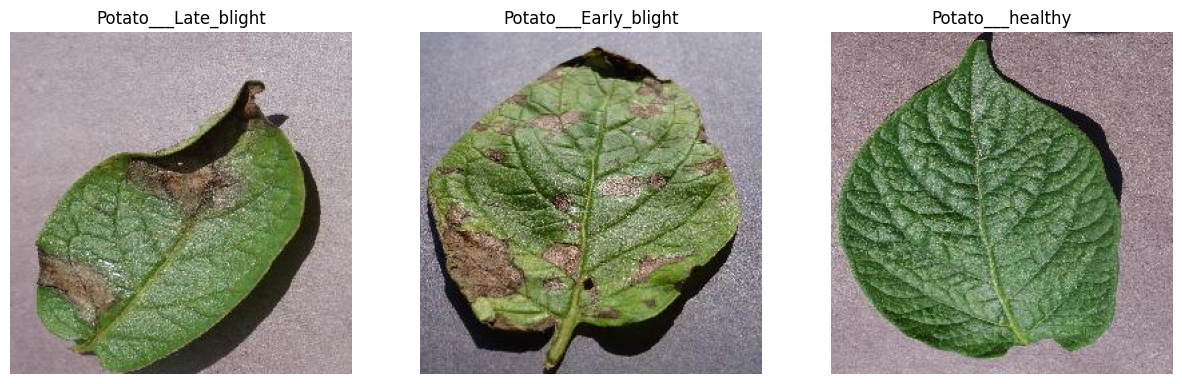

In [ ]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
  image_name = os.listdir(os.path.join(train_path,folder))[0]
  image_path = os.path.join(train_path,folder,image_name)
  image = cv2.imread(image_path)
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  plt.subplot(1,3,i+1)
  plt.imshow(image)
  plt.title(folder)
  plt.axis("off")
plt.show()


In [ ]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)

In [ ]:
X_train = []
y_train = []

X_val = []
y_val = []

In [ ]:
for label in os.listdir(train_path):
  folder_path=os.path.join(train_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_train.append(image)
    y_train.append(label)
print("Training Images Loaded Successfully")

Training Images Loaded Successfully


In [ ]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path,label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image,image_size)
    X_val.append(image)
    y_val.append(label)
print("Validation Images loaded successfully")

Validation Images loaded successfully


In [ ]:
print("Traing images:", len(X_train))
print("Training labels:", len(y_train))
print()
print("validation images:",len(X_val))
print("validation labels:",len(y_val))

Traing images: 1721
Training labels: 1721

validation images: 431
validation labels: 431


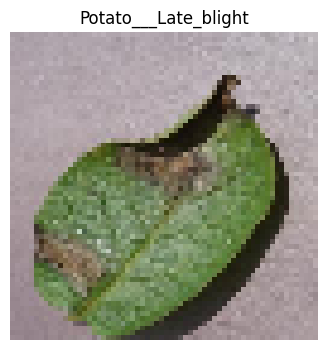

In [ ]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [ ]:
X_train = np.array(X_train)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_val = np.array(y_val)
print("Converted successfully")

Converted successfully


In [ ]:
X_train.shape

(1721, 64, 64, 3)

In [ ]:
X_val.shape

(431, 64, 64, 3)

In [ ]:
X_train = X_train.reshape(X_train.shape[0],-1)
X_val = X_val.reshape(X_val.shape[0],-1)

print("Images Flattened Successfully")

Images Flattened Successfully


In [ ]:
X_train.shape

(1721, 12288)

In [ ]:
X_val.shape

(431, 12288)

In [ ]:
X_train = X_train/255.0
X_val = X_val/255.0

print("Normalization Completed!")

Normalization Completed!


In [ ]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)

print("Labels Encoded Successfully")

Labels Encoded Successfully


In [ ]:
print("Encoded Classes:")
print(encoder.classes_)

print()
print("First 10 labels:")
print(y_train[:10])

Encoded Classes:
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 labels:
[1 1 1 1 1 1 1 1 1 1]


In [ ]:
print("Training features shape:",X_train.shape)
print("Training labels shape:",y_train.shape)
print()
print("Validation features shape:",X_val.shape)
print("Validation labels shape:",y_val.shape)

Training features shape: (1721, 12288)
Training labels shape: (1721,)

Validation features shape: (431, 12288)
Validation labels shape: (431,)


In [ ]:
X_val.shape

(431, 12288)

In [ ]:
logistic_model = LogisticRegression(max_iter=1000)
print("Logistic Regression Model Created Successfully")

Logistic Regression Model Created Successfully


In [ ]:
logistic_model.fit(X_train,y_train)
print("Model training is completed")

Model training is completed


In [ ]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [ ]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Actual labels: [1 1 1 1 1 1 1 1 1 1]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]


In [ ]:
acc = accuracy_score(y_val,y_pred)
print("Accuracy:",round(acc*100,2),"%")

Accuracy: 90.95 %


In [ ]:
cmx = confusion_matrix(y_val,y_pred)
print("Confusion matrix is:\n",cmx)

Confusion matrix is:
 [[186  14   0]
 [  8 189   3]
 [  0  14  17]]


In [ ]:
print(classification_report(y_val,y_pred,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.91       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.91       431



In [41]:
predicted_labels = encoder.inverse_transform(y_pred[:10])

print("First 10 Predicted Disease Names:")
print(predicted_labels)

First 10 Predicted Disease Names:
['Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight']


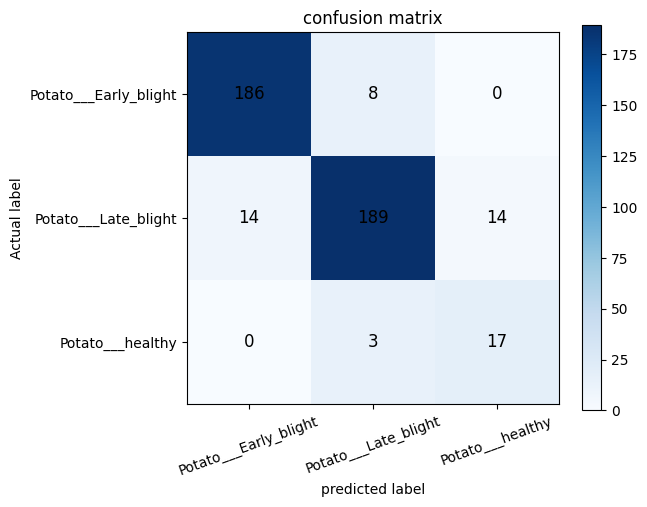

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Blues")
plt.title("confusion matrix")
plt.colorbar()

plt.xticks(range(3),encoder.classes_,rotation=20)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(cmx[i])):
    plt.text(j, i, cmx[j][i],
             ha="center",
             va="center",
             fontsize=12)
plt.xlabel("predicted label")
plt.ylabel("Actual label")
plt.show()

In [44]:
print("="*40)
print("logistic regression completed successfully!")
print("="*40)

print(f"Accuracy : {acc*100:.2f}%")


logistic regression completed successfully!
Accuracy : 90.95%


In [47]:
svm_model = SVC(kernel="linear")
print("support vector machine model created successfully")

support vector machine model created successfully


In [48]:
svm_fit = svm_model.fit(X_train,y_train)
print("model training completed")

model training completed


In [49]:
y_pred = svm_fit.predict(X_val)
print("prediction completed")

prediction completed


In [71]:
svm_acc = accuracy_score(y_val, y_pred)
print(f"Accuracy for SVM: {acc_svm * 100:.2f}%")

Accuracy for SVM: 91.18%


In [59]:
cm = confusion_matrix(y_val, y_pred)
print("Confusion matrix is:\n", cm)

Confusion matrix is:
 [[183  17   0]
 [  9 188   3]
 [  1   8  22]]


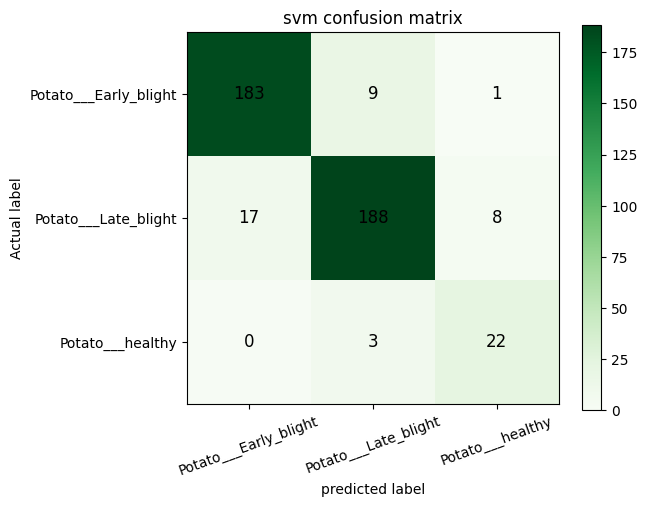

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm,cmap="Greens")
plt.title("svm confusion matrix")
plt.colorbar()

plt.xticks(range(3),encoder.classes_,rotation=20)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cm)):
  for j in range(len(cm[i])):
    plt.text(j, i, cm[j][i],
             ha="center",
             va="center",
             fontsize=12)
plt.xlabel("predicted label")
plt.ylabel("Actual label")
plt.show()

In [74]:
print("="*40)
print("SVM completed successfully!")
print("="*40)

print(f"Accuracy : {svm_acc*100:.2f}%")


SVM completed successfully!
Accuracy : 91.18%


In [ ]:
from google.colab import files
uploaded = files.upload()

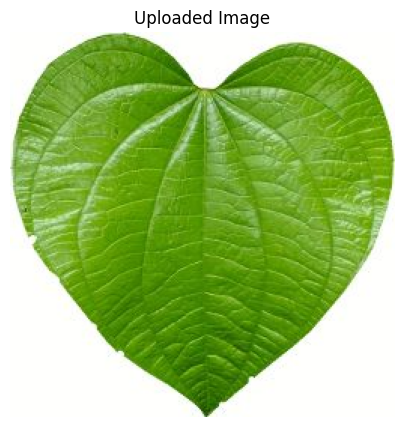

In [82]:
image_name = list(uploaded.keys())[0]
image = cv2.imread(image_name)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [83]:
test_image = cv2.resize(image,(64,64))
test_image = test_image.reshape(1,-1)
test_image = test_image/255.0
print("image processed successfully!")

image processed successfully!


In [84]:
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease:",predicted_disease[0])

Predicted Disease: Potato___healthy


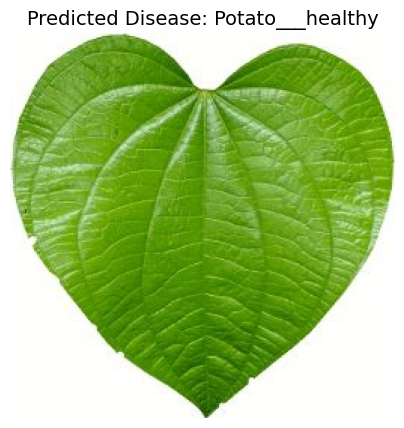

In [85]:
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title(f"Predicted Disease: " +predicted_disease[0],fontsize = 14)
plt.axis("off")
plt.show()

In [ ]:
if predicted_disease[0] == 'Potato___Early_blight':
  print("Early Blight")
  print("advice : remove inflected leaves and apply a suitable")
elif predicted_disease[0] == 'Potato___Late_blight':
  print("Late Blight")
  print("Advice : improve drainage , and overhead watering")
elif predicted_disease[0] == 'Potato___healthy':
  print("Healthy")
  print("advice : no disease detected. continue regular crop care.")

In [ ]:
comparison = {
    "Model" : ["Logistic regression","support vector machine"],
    "Accuracy" : [acc*100,svm_acc*100]
}
import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df


In [ ]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model accuracy comparison")
plt.xlabel("Machine learning model")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.show()

In [ ]:
if svm_acc > accuracy:
  print("Best model : support vector machine")
else:
  print("Best model : logistic regression")